# 单个 fold 重建音频可视化

这个 notebook 用于快速检查一个 `(S, M)` fold 的原始音频与重建音频。主流程只保留音频加载、低频 spectrogram、F0 confidence 诊断和 F0 可视化；数据集级 RPA/RCA、note-level 评分和时间偏移扫描请在本目录其他分析 notebook 中完成。

F0 提取和缓存沿用 `pitch_analysis_shared.py` / `f0_backends.py`，避免在 notebook 内重复维护 estimator 实现。

## 1. 选择 fold 与显示参数

通常只需要修改 `RESULT_ROOT`、`S_ID`、`M_ID` 和 `AUDIO_CONDITION`。`VIEW_START_SEC` / `VIEW_END_SEC` 可用于放大局部时间段。

In [54]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import stft
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, ScalarFormatter
from IPython.display import Audio, display


def find_project_root(start=Path.cwd()):
    """从项目根目录、adaptation 或 notebook 目录启动时都能定位项目。"""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        shared_module = candidate / "adaptation" / "Res_Ana_F0" / "pitch_analysis_shared.py"
        if shared_module.is_file():
            return candidate
    raise FileNotFoundError("无法定位 Neu2Sound 项目根目录。")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "adaptation" / "Res_Ana_F0"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from f0_backends import extract_f0
from pitch_analysis_shared import (
    F0Track,
    aggregate_fold_metrics,
    backend_configs,
    evaluate_pitch,
    load_audio_mono,
    load_or_extract_tracks,
    midi_to_hz,
)

# ============================================================
# 单个 fold：主要修改这里
# ============================================================
RESULT_ROOT = PROJECT_ROOT / "adaptation" / "results_20260901_ZJM_TCN_dynamics_v2_100folds"
REFERENCE_AUDIO_DIR = Path("/data/zhj/audio_VAE/data")
S_ID = 2
M_ID = 5
# 2/5
# ? 8/6 6/5 1/6
# X 6/9 2/10 9/9
AUDIO_CONDITION = "clean"  # clean / SM(0.6|1.8|3.0) / TM(1.0|2.0|3.5)

# F0 使用项目统一配置；clean/SM 优先读取已有 cache。
F0_BACKEND = "crepe"
ALLOW_F0_EXTRACTION = True
CONFIDENCE_THRESHOLDS = [0.1, 0.3, 0.5]
PRIMARY_CONFIDENCE_THRESHOLD = 0.5
METRIC_EVALUATION_LEVELS = ("frame", "note")
PITCH_TOLERANCE_HALF_WIDTH_CENTS = 50.0
NOTE_F0_AGGREGATION = "median"
MIN_CONFIDENT_FRAMES_PER_NOTE = 1
F0_DISPLAY_PADDING_SEMITONES = 1.0

# 局部观察范围；VIEW_END_SEC=None 表示显示到音频末尾。
VIEW_START_SEC = 0.0
VIEW_END_SEC = None


def apply_time_view(ax):
    if VIEW_END_SEC is not None:
        ax.set_xlim(VIEW_START_SEC, VIEW_END_SEC)
    elif VIEW_START_SEC > 0:
        ax.set_xlim(left=VIEW_START_SEC)

# 低频谐波 spectrogram 参数。
SPECTROGRAM_FMIN_HZ = 100.0
SPECTROGRAM_FMAX_HZ = 1200.0
SPECTROGRAM_N_FFT = 4096
SPECTROGRAM_HOP_LENGTH = 512
SPECTROGRAM_DYNAMIC_RANGE_DB = 80.0

ALLOWED_CONDITIONS = {
    "clean", "SM(0.6)", "SM(1.8)", "SM(3.0)",
    "TM(1.0)", "TM(2.0)", "TM(3.5)",
}
CACHEABLE_F0_CONDITIONS = {"clean", "SM(0.6)", "SM(1.8)", "SM(3.0)"}
if AUDIO_CONDITION not in ALLOWED_CONDITIONS:
    raise ValueError(f"不支持的 AUDIO_CONDITION={AUDIO_CONDITION!r}")

FOLD_DIR = RESULT_ROOT / f"S{S_ID}_M{M_ID}"
config_path = FOLD_DIR / "config.json"
if not config_path.is_file():
    raise FileNotFoundError(f"缺少 fold 配置：{config_path}")
with config_path.open(encoding="utf-8") as file:
    run_config = json.load(file)

config_s_id = int(run_config.get("data_loader", {}).get("S_idx", S_ID))
config_m_id = int(run_config.get("data_loader", {}).get("M_idx", M_ID))
if (config_s_id, config_m_id) != (S_ID, M_ID):
    raise ValueError(
        f"fold 路径是 S{S_ID}_M{M_ID}，但 config.json 记录的是 "
        f"S{config_s_id}_M{config_m_id}"
    )

SR = int(run_config.get("loss", {}).get("spectral", {}).get("sample_rate", 48_000))
if AUDIO_CONDITION == "clean":
    ref_filename = f"English_S{S_ID}_M{M_ID}_SM(0.0).wav"
    pred_filename = f"recon_English_S{S_ID}_M{M_ID}.wav"
else:
    ref_filename = f"English_S{S_ID}_M{M_ID}_{AUDIO_CONDITION}.wav"
    pred_filename = f"recons_English_S{S_ID}_M{M_ID}_{AUDIO_CONDITION}.wav"

ref_audio_path = REFERENCE_AUDIO_DIR / ref_filename
pred_audio_path = FOLD_DIR / pred_filename
missing_paths = [path for path in (ref_audio_path, pred_audio_path) if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"缺少音频文件：{missing_paths}")

summary_path = FOLD_DIR / "summary.json"
run_summary = {}
if summary_path.is_file():
    with summary_path.open(encoding="utf-8") as file:
        run_summary = json.load(file)

pair_id = f"S{S_ID}_M{M_ID}_{AUDIO_CONDITION}"
print(f"pair: {pair_id}")
print(f"fold: {FOLD_DIR}")
print(f"reference: {ref_audio_path}")
print(f"reconstructed: {pred_audio_path}")


pair: S2_M5_clean
fold: /home/zhj/projs/Neu2Sound/adaptation/results_20260901_ZJM_TCN_dynamics_v2_100folds/S2_M5
reference: /data/zhj/audio_VAE/data/English_S2_M5_SM(0.0).wav
reconstructed: /home/zhj/projs/Neu2Sound/adaptation/results_20260901_ZJM_TCN_dynamics_v2_100folds/S2_M5/recon_English_S2_M5.wav


## 2. 加载音频与 fold 摘要

音频统一转为 mono，并按 fold 配置中的 spectral sample rate 重采样。这里仅展示必要元数据和两个播放器。

In [55]:
ref_audio = load_audio_mono(ref_audio_path, SR)
pred_audio = load_audio_mono(pred_audio_path, SR)

fold_summary = pd.DataFrame([{
    "pair_id": pair_id,
    "status": run_summary.get("status", "unknown"),
    "best_epoch": run_summary.get("best_epoch", np.nan),
    "best_val_loss": run_summary.get("best_val_loss", np.nan),
    "sample_rate": SR,
    "f0_backend": F0_BACKEND,
}])
display(fold_summary)

audio_info = pd.DataFrame([
    {
        "audio": "Original",
        "path": str(ref_audio_path),
        "file_sr": sf.info(ref_audio_path).samplerate,
        "analysis_sr": SR,
        "samples": len(ref_audio),
        "duration_sec": len(ref_audio) / SR,
    },
    {
        "audio": "Reconstructed",
        "path": str(pred_audio_path),
        "file_sr": sf.info(pred_audio_path).samplerate,
        "analysis_sr": SR,
        "samples": len(pred_audio),
        "duration_sec": len(pred_audio) / SR,
    },
])
display(audio_info)
print(
    f"Length difference: {len(pred_audio) - len(ref_audio)} samples "
    f"({(len(pred_audio) - len(ref_audio)) / SR:+.4f} s)"
)

print("Original audio")
display(Audio(ref_audio, rate=SR))
print("Reconstructed audio")
display(Audio(pred_audio, rate=SR))


,pair_id,status,best_epoch,best_val_loss,sample_rate,f0_backend
0,S2_M5_clean,completed,2997,0.332252,48000,crepe


,audio,path,file_sr,analysis_sr,samples,duration_sec
0,Original,/data/zhj/audio_VAE/data/English_S2_M5_SM(0.0)...,48000,48000,201600,4.200000
1,Reconstructed,/home/zhj/projs/Neu2Sound/adaptation/results_2...,48000,48000,214528,4.469333


Length difference: 12928 samples (+0.2693 s)
Original audio


Reconstructed audio


## 3. 100–1200 Hz 低频 spectrogram

两幅图使用相同 STFT 参数、同一个 100–1200 Hz 频段峰值作为 `0 dB`，并共享 `−80–0 dB` colorbar，因此颜色可直接比较。

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

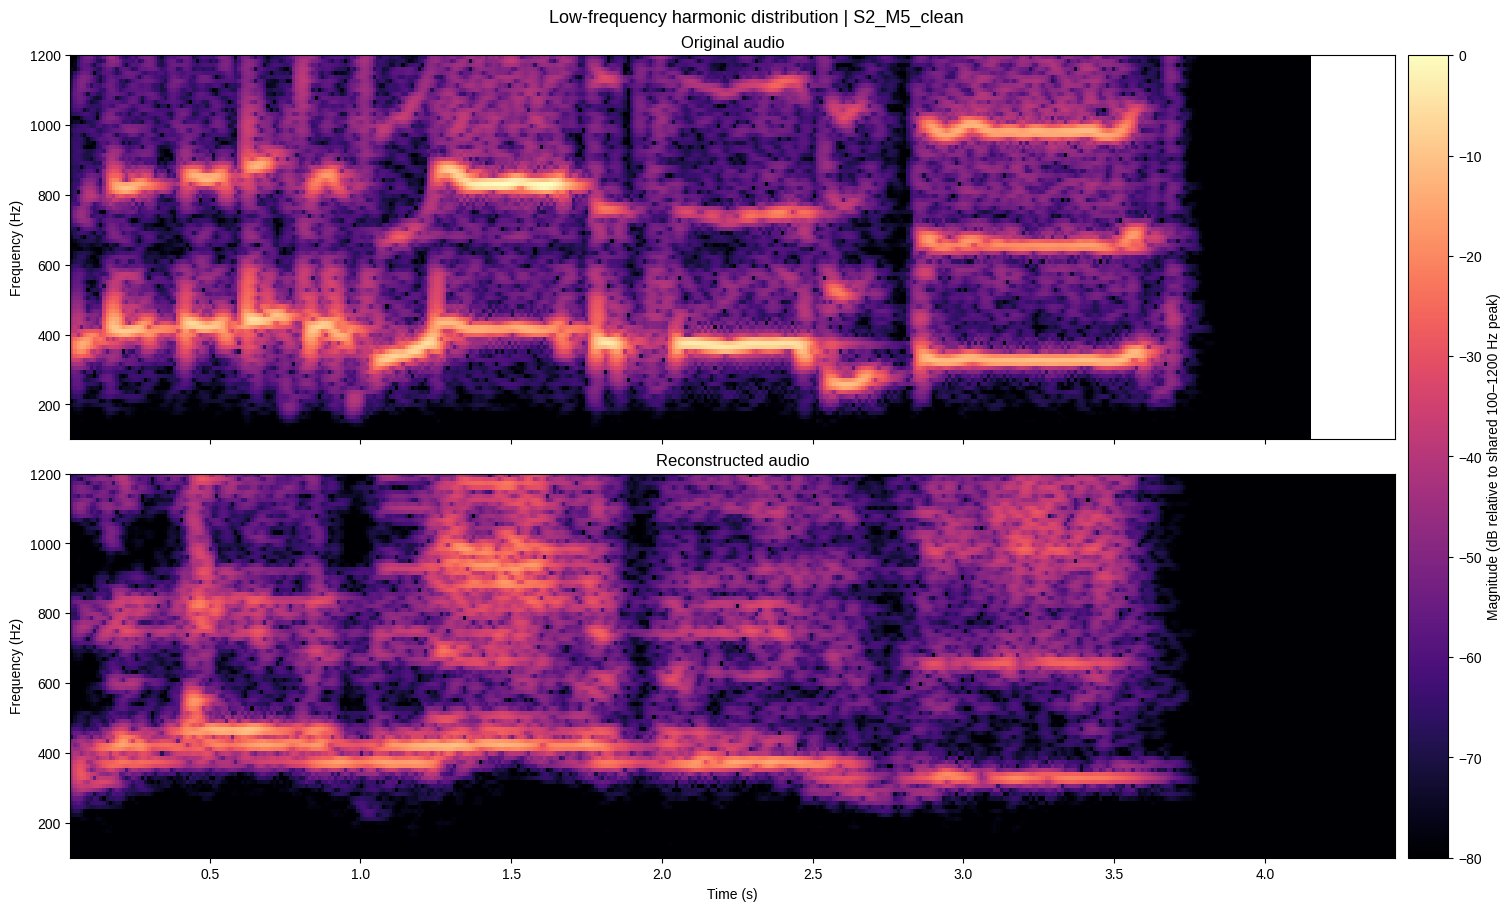

In [56]:
def compute_stft_magnitude(audio, sr, n_fft, hop_length):
    frequencies, times, spectrum = stft(
        audio,
        fs=sr,
        window="hann",
        nperseg=n_fft,
        noverlap=n_fft - hop_length,
        nfft=n_fft,
        detrend=False,
        return_onesided=True,
        boundary=None,
        padded=False,
    )
    return frequencies, times, np.abs(spectrum)


ref_spec_freqs, ref_spec_times, ref_spec_magnitude = compute_stft_magnitude(
    ref_audio, SR, SPECTROGRAM_N_FFT, SPECTROGRAM_HOP_LENGTH
)
pred_spec_freqs, pred_spec_times, pred_spec_magnitude = compute_stft_magnitude(
    pred_audio, SR, SPECTROGRAM_N_FFT, SPECTROGRAM_HOP_LENGTH
)
ref_band_mask = (ref_spec_freqs >= SPECTROGRAM_FMIN_HZ) & (ref_spec_freqs <= SPECTROGRAM_FMAX_HZ)
pred_band_mask = (pred_spec_freqs >= SPECTROGRAM_FMIN_HZ) & (pred_spec_freqs <= SPECTROGRAM_FMAX_HZ)
shared_band_peak = max(
    float(ref_spec_magnitude[ref_band_mask].max()),
    float(pred_spec_magnitude[pred_band_mask].max()),
    np.finfo(np.float32).tiny,
)
minimum_relative_magnitude = 10.0 ** (-SPECTROGRAM_DYNAMIC_RANGE_DB / 20.0)
ref_spec_db = 20.0 * np.log10(
    np.maximum(ref_spec_magnitude / shared_band_peak, minimum_relative_magnitude)
)
pred_spec_db = 20.0 * np.log10(
    np.maximum(pred_spec_magnitude / shared_band_peak, minimum_relative_magnitude)
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=True, constrained_layout=True)
spectrogram_items = [
    (axes[0], "Original audio", ref_spec_times, ref_spec_freqs, ref_spec_db, ref_band_mask),
    (axes[1], "Reconstructed audio", pred_spec_times, pred_spec_freqs, pred_spec_db, pred_band_mask),
]
mesh = None
for ax, title, times, frequencies, spectrum_db, band_mask in spectrogram_items:
    mesh = ax.pcolormesh(
        times,
        frequencies[band_mask],
        spectrum_db[band_mask],
        shading="auto",
        cmap="magma",
        vmin=-SPECTROGRAM_DYNAMIC_RANGE_DB,
        vmax=0.0,
        rasterized=True,
    )
    ax.set_ylim(SPECTROGRAM_FMIN_HZ, SPECTROGRAM_FMAX_HZ)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(title)
    apply_time_view(ax)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Low-frequency harmonic distribution | {pair_id}", fontsize=13)
colorbar = fig.colorbar(mesh, ax=axes, pad=0.01)
colorbar.set_label("Magnitude (dB relative to shared 100–1200 Hz peak)")
plt.show()


## 4. 获取 F0 轨迹

这里不再计算 RPA/RCA。clean 和 SM 条件通过项目共享函数优先读取已有 F0 cache；只有 cache 缺失且 `ALLOW_F0_EXTRACTION=True` 时才重新提取。TM 尚无共享 cache 命名约定，因此直接调用统一后端。

In [57]:
all_f0_configs = backend_configs(SR)
if F0_BACKEND not in all_f0_configs:
    raise ValueError(f"不支持的 F0_BACKEND={F0_BACKEND!r}；可选：{sorted(all_f0_configs)}")
f0_config = all_f0_configs[F0_BACKEND].copy()
pair_record = {
    "key": (S_ID, M_ID),
    "S": S_ID,
    "M": M_ID,
    "condition": AUDIO_CONDITION,
    "ref_path": ref_audio_path,
    "pred_path": pred_audio_path,
}

if AUDIO_CONDITION in CACHEABLE_F0_CONDITIONS:
    cached_tracks, f0_cache_path, f0_cache_status = load_or_extract_tracks(
        [pair_record],
        result_root=RESULT_ROOT,
        backend=F0_BACKEND,
        config=f0_config,
        condition=AUDIO_CONDITION,
        allow_extraction=ALLOW_F0_EXTRACTION,
    )
    f0_tracks = cached_tracks[(S_ID, M_ID)]
else:
    def extract_track(audio):
        f0_hz, confidence, time_sec = extract_f0(audio, SR, F0_BACKEND, f0_config)
        return F0Track(f0_hz, confidence, time_sec, F0_BACKEND)

    f0_tracks = {
        "reference": extract_track(ref_audio),
        "reconstructed": extract_track(pred_audio),
    }
    f0_cache_path = None
    f0_cache_status = "direct_extraction_no_tm_cache"


def summarize_f0_track(name, track):
    valid = np.isfinite(track.f0_hz) & (track.f0_hz > 0)
    return {
        "audio": name,
        "frames": len(track.f0_hz),
        "valid_f0_frames": int(valid.sum()),
        "median_f0_hz_valid": float(np.median(track.f0_hz[valid])) if valid.any() else np.nan,
        "median_confidence_valid": float(np.median(track.confidence[valid])) if valid.any() else np.nan,
    }


print(f"F0 source: {f0_cache_status}")
if f0_cache_path is not None:
    print(f"F0 cache: {f0_cache_path}")
f0_summary = pd.DataFrame([
    summarize_f0_track("Original", f0_tracks["reference"]),
    summarize_f0_track("Reconstructed", f0_tracks["reconstructed"]),
])
display(f0_summary.style.format({
    "median_f0_hz_valid": "{:.1f}",
    "median_confidence_valid": "{:.3f}",
}))


F0 source: cache_hit_100fold_subset
F0 cache: /home/zhj/projs/Neu2Sound/adaptation/results_20260901_ZJM_TCN_dynamics_v2_100folds/f0_estimator_cache/f0_tracks__monkey-ZJM__condition-clean__roles-original-reconstructed__estimator-crepe__scope-100folds-08e865d0.npz


,audio,frames,valid_f0_frames,median_f0_hz_valid,median_confidence_valid
0,Original,841,841,372.1,0.860
1,Reconstructed,894,894,370.1,0.650


## 6. RPA_orig、RPA_recon 与 PDA

结果同时报告 pitch accuracy 与允许整数八度等价的 RCA。`RPA_orig`/`RPA_recon` 的分母包含 Human note 区间内所有 observation，因此 estimator 未通过 confidence mask 会降低 RPA；`PDA` 是 O∩R 都通过相同 mask 后的条件准确率，必须结合 `pda_candidate_recall` 阅读。

In [58]:
# Rebuild the note-level metric input removed with the former cell 5.
annotation_path = ANALYSIS_DIR / "english_note_annotations.json"
metric_contract_path = ANALYSIS_DIR / "PITCH_METRIC_CONTRACT.md"
with annotation_path.open(encoding="utf-8") as file:
    annotation_data = json.load(file)
recording_annotation = next(
    record
    for record in annotation_data["recordings"]
    if int(record["S"]) == S_ID and int(record["M"]) == M_ID
)
note_table = pd.DataFrame(recording_annotation["notes"]).copy()
note_table["label_hz"] = midi_to_hz(note_table["label_midi"].to_numpy())
metric_notes = []
for note in note_table.to_dict(orient="records"):
    note_index = int(note["note_index"])
    metric_notes.append({
        **note,
        "note_uid": f"S{S_ID:02d}_M{M_ID:02d}_N{note_index:02d}",
        "seen_group": "not_used_single_case",
        "n_train_notes_same_pitch": -1,
        "train_pitch_probability": np.nan,
    })
metric_pair_record = {**pair_record, "notes": metric_notes}

raw_metrics_by_level = {}
metric_summary_parts = []
single_case_tracks = {(S_ID, M_ID): f0_tracks}
for evaluation_level in METRIC_EVALUATION_LEVELS:
    raw_metrics = evaluate_pitch(
        [metric_pair_record],
        single_case_tracks,
        level=evaluation_level,
        thresholds=CONFIDENCE_THRESHOLDS,
        tolerance_cents=PITCH_TOLERANCE_HALF_WIDTH_CENTS,
        note_aggregation=NOTE_F0_AGGREGATION,
        min_confident_frames=MIN_CONFIDENT_FRAMES_PER_NOTE,
    )
    raw_metrics_by_level[evaluation_level] = raw_metrics
    metric_summary_parts.append(aggregate_fold_metrics(raw_metrics, metric="pda"))

pitch_metric_summary = pd.concat(metric_summary_parts, ignore_index=True)
level_order = {level: index for index, level in enumerate(METRIC_EVALUATION_LEVELS)}
pitch_metric_summary["_level_order"] = pitch_metric_summary["level"].map(level_order)
pitch_metric_summary = pitch_metric_summary.sort_values(
    ["_level_order", "confidence_threshold"]
).drop(columns="_level_order").reset_index(drop=True)

metric_summary_columns = [
    "level", "confidence_threshold",
    "rpa_orig", "rpa_recon", "pda",
    "rca_orig", "rca_recon", "rca_pda",
    "original_voiced_recall", "reconstructed_voiced_recall", "pda_candidate_recall",
    "n_human_voiced", "n_original_voiced", "n_reconstructed_voiced",
    "n_original_reconstructed_voiced",
]
metric_rate_columns = [
    "rpa_orig", "rpa_recon", "pda",
    "rca_orig", "rca_recon", "rca_pda",
    "original_voiced_recall", "reconstructed_voiced_recall", "pda_candidate_recall",
]
metric_formats = {column: "{:.4f}" for column in metric_rate_columns}
metric_formats["confidence_threshold"] = "{:.2f}"
display(pitch_metric_summary[metric_summary_columns].style.format(metric_formats))

primary_rows = pitch_metric_summary.loc[
    np.isclose(pitch_metric_summary["confidence_threshold"], PRIMARY_CONFIDENCE_THRESHOLD)
]
primary_specs = {
    "RPA_orig": ("rpa_orig", "n_rpa_orig_correct", "n_human_voiced", "original_voiced_recall"),
    "RPA_recon": ("rpa_recon", "n_rpa_recon_correct", "n_human_voiced", "reconstructed_voiced_recall"),
    "PDA": ("pda", "n_pda_correct", "n_original_reconstructed_voiced", "pda_candidate_recall"),
}
primary_detail_rows = []
for row in primary_rows.itertuples(index=False):
    for metric_name, (value_col, numerator_col, denominator_col, coverage_col) in primary_specs.items():
        primary_detail_rows.append({
            "level": row.level,
            "metric": metric_name,
            "confidence_threshold": row.confidence_threshold,
            "correct_numerator": int(getattr(row, numerator_col)),
            "denominator": int(getattr(row, denominator_col)),
            "accuracy": float(getattr(row, value_col)),
            "candidate_recall": float(getattr(row, coverage_col)),
        })
primary_metric_detail = pd.DataFrame(primary_detail_rows)
display(primary_metric_detail.style.format({
    "confidence_threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "candidate_recall": "{:.4f}",
}))

# 口径与计算完整性检查。
assert len(primary_rows) == len(METRIC_EVALUATION_LEVELS)
assert np.allclose(
    pitch_metric_summary["original_confidence_threshold"],
    pitch_metric_summary["reconstructed_confidence_threshold"],
)
for column in metric_rate_columns:
    assert pitch_metric_summary[column].dropna().between(0.0, 1.0).all()
for pitch_column, chroma_column in [("rpa_orig", "rca_orig"), ("rpa_recon", "rca_recon"), ("pda", "rca_pda")]:
    valid = pitch_metric_summary[[pitch_column, chroma_column]].dropna()
    assert (valid[chroma_column] + 1e-12 >= valid[pitch_column]).all()
for detail in primary_metric_detail.itertuples(index=False):
    expected = detail.correct_numerator / detail.denominator if detail.denominator else np.nan
    assert np.isclose(detail.accuracy, expected, equal_nan=True)
print("Single-case H/O/R pitch metric checks passed.")


,level,confidence_threshold,rpa_orig,rpa_recon,pda,rca_orig,rca_recon,rca_pda,original_voiced_recall,reconstructed_voiced_recall,pda_candidate_recall,n_human_voiced,n_original_voiced,n_reconstructed_voiced,n_original_reconstructed_voiced
0,frame,0.10,0.6851,0.6684,0.5534,0.6851,0.6684,0.5534,0.9422,0.9846,0.9959,778,733,766,730
1,frame,0.30,0.6645,0.6375,0.5773,0.6645,0.6375,0.5773,0.8959,0.9280,0.9469,778,697,722,660
2,frame,0.50,0.6247,0.5643,0.6418,0.6247,0.5643,0.6418,0.8290,0.7725,0.8093,778,645,601,522
3,note,0.10,0.8000,0.6000,0.6000,0.8000,0.6000,0.6000,1.0000,1.0000,1.0000,10,10,10,10
4,note,0.30,0.8000,0.6000,0.6000,0.8000,0.6000,0.6000,1.0000,1.0000,1.0000,10,10,10,10
5,note,0.50,0.8000,0.6000,0.6000,0.8000,0.6000,0.6000,1.0000,1.0000,1.0000,10,10,10,10


,level,metric,confidence_threshold,correct_numerator,denominator,accuracy,candidate_recall
0,frame,RPA_orig,0.50,486,778,0.6247,0.8290
1,frame,RPA_recon,0.50,439,778,0.5643,0.7725
2,frame,PDA,0.50,335,522,0.6418,0.8093
3,note,RPA_orig,0.50,8,10,0.8000,1.0000
4,note,RPA_recon,0.50,6,10,0.6000,1.0000
5,note,PDA,0.50,6,10,0.6000,1.0000


Single-case H/O/R pitch metric checks passed.


## 7. Confidence 与 mask 诊断

threshold 只用于统计各自音频会保留多少有效 F0 frame，不参与后面的 F0 绘图筛选。时间轨迹和直方图使用 estimator 返回的全部有限 confidence，用于观察当前单例的 confidence 分布。

,audio,confidence_threshold,valid_f0_frames,selected_frames,selected_ratio_of_valid_f0
0,Original,0.10,841,789,0.938
1,Original,0.30,841,697,0.829
2,Original,0.50,841,645,0.767
3,Reconstructed,0.10,894,777,0.869
4,Reconstructed,0.30,894,723,0.809
5,Reconstructed,0.50,894,601,0.672


,audio,num_frames,mean,median,p10,p90,ratio_>0.10,ratio_>0.30,ratio_>0.50
0,Original,841,0.707,0.860,0.141,0.967,0.938,0.829,0.767
1,Reconstructed,894,0.590,0.650,0.026,0.934,0.869,0.809,0.672


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

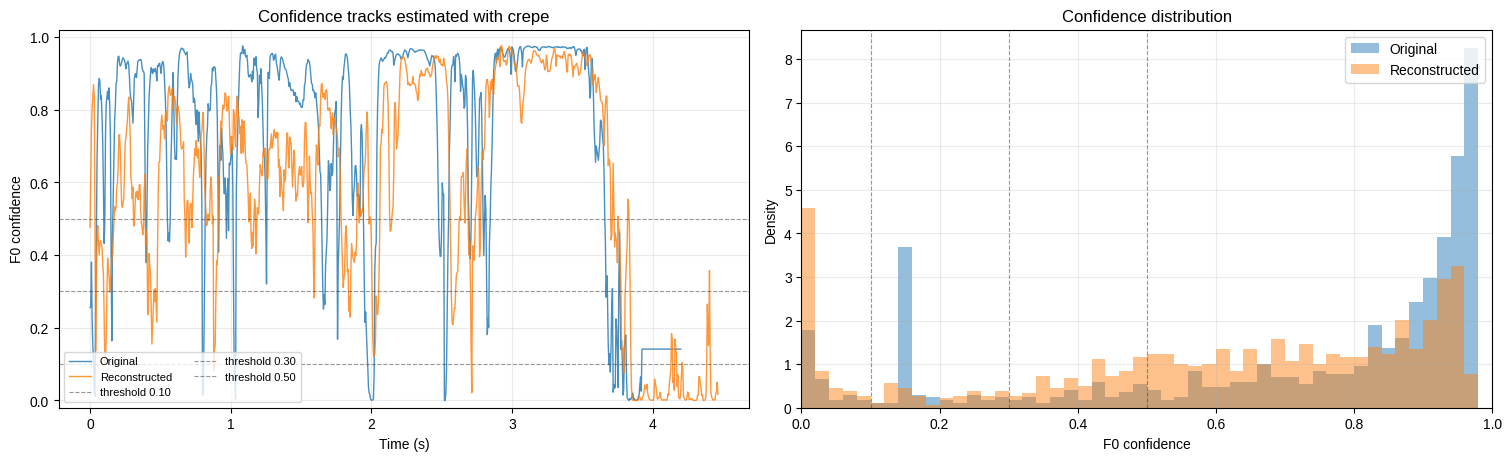

In [59]:
track_items = [
    ("Original", f0_tracks["reference"], "tab:blue"),
    ("Reconstructed", f0_tracks["reconstructed"], "tab:orange"),
]
mask_rows = []
confidence_rows = []
for audio_name, track, _ in track_items:
    finite_confidence = np.isfinite(track.confidence)
    confidence_values = track.confidence[finite_confidence]
    valid_f0 = np.isfinite(track.f0_hz) & (track.f0_hz > 0) & finite_confidence

    confidence_row = {
        "audio": audio_name,
        "num_frames": int(len(confidence_values)),
        "mean": float(np.mean(confidence_values)) if len(confidence_values) else np.nan,
        "median": float(np.median(confidence_values)) if len(confidence_values) else np.nan,
        "p10": float(np.percentile(confidence_values, 10)) if len(confidence_values) else np.nan,
        "p90": float(np.percentile(confidence_values, 90)) if len(confidence_values) else np.nan,
    }
    for threshold in CONFIDENCE_THRESHOLDS:
        selected = valid_f0 & (track.confidence > threshold)
        mask_rows.append({
            "audio": audio_name,
            "confidence_threshold": threshold,
            "valid_f0_frames": int(valid_f0.sum()),
            "selected_frames": int(selected.sum()),
            "selected_ratio_of_valid_f0": float(selected.sum() / max(valid_f0.sum(), 1)),
        })
        confidence_row[f"ratio_>{threshold:.2f}"] = (
            float(np.mean(confidence_values > threshold)) if len(confidence_values) else np.nan
        )
    confidence_rows.append(confidence_row)

mask_summary = pd.DataFrame(mask_rows)
confidence_summary = pd.DataFrame(confidence_rows)
display(mask_summary.style.format({
    "confidence_threshold": "{:.2f}",
    "selected_ratio_of_valid_f0": "{:.3f}",
}))
confidence_format = {"mean": "{:.3f}", "median": "{:.3f}", "p10": "{:.3f}", "p90": "{:.3f}"}
confidence_format.update({f"ratio_>{threshold:.2f}": "{:.3f}" for threshold in CONFIDENCE_THRESHOLDS})
display(confidence_summary.style.format(confidence_format))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
for audio_name, track, color in track_items:
    axes[0].plot(
        track.time_sec, track.confidence,
        color=color, linewidth=1.0, alpha=0.82, label=audio_name,
    )
    confidence_values = track.confidence[np.isfinite(track.confidence)]
    axes[1].hist(
        confidence_values, bins=np.linspace(0.0, 1.0, 51), density=True,
        color=color, alpha=0.48, label=audio_name,
    )
for threshold in CONFIDENCE_THRESHOLDS:
    axes[0].axhline(
        threshold, color="0.25", linestyle="--", linewidth=0.8, alpha=0.55,
        label=f"threshold {threshold:.2f}",
    )
    axes[1].axvline(threshold, color="0.25", linestyle="--", linewidth=0.8, alpha=0.55)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("F0 confidence")
axes[0].set_title(f"Confidence tracks estimated with {F0_BACKEND}")
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=2, fontsize=8)
apply_time_view(axes[0])
axes[1].set_xlim(0.0, 1.0)
axes[1].set_xlabel("F0 confidence")
axes[1].set_ylabel("Density")
axes[1].set_title("Confidence distribution")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()


## 8. F0 与人工 note 标注可视化

所有有效 F0 frame 都会绘制，不使用 threshold 过滤；Original / Reconstructed 分别用蓝色和橙色，confidence 通过透明度表示。红线来自 `english_note_annotations.json` 的 `label_midi`。该人工标注以 clean 音频时间轴为准，在 SM/TM 条件下只作为时间与音高参照，不代表对降质音频重新标注的声学真值。

,note_index,start_time_s,end_time_s,label_midi,label_hz
0,1,0.000000,0.360906,68,415.304698
1,2,0.360906,0.584674,68,415.304698
2,3,0.584674,0.791448,69,440.000000
3,4,0.791448,1.009552,68,415.304698
4,5,1.009552,1.224824,64,329.627557
5,6,1.224824,1.731844,68,415.304698
6,7,1.731844,1.964111,66,369.994423
7,8,1.964111,2.516452,66,369.994423
8,9,2.516452,2.757216,61,277.182631
9,10,2.757216,3.886670,64,329.627557


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

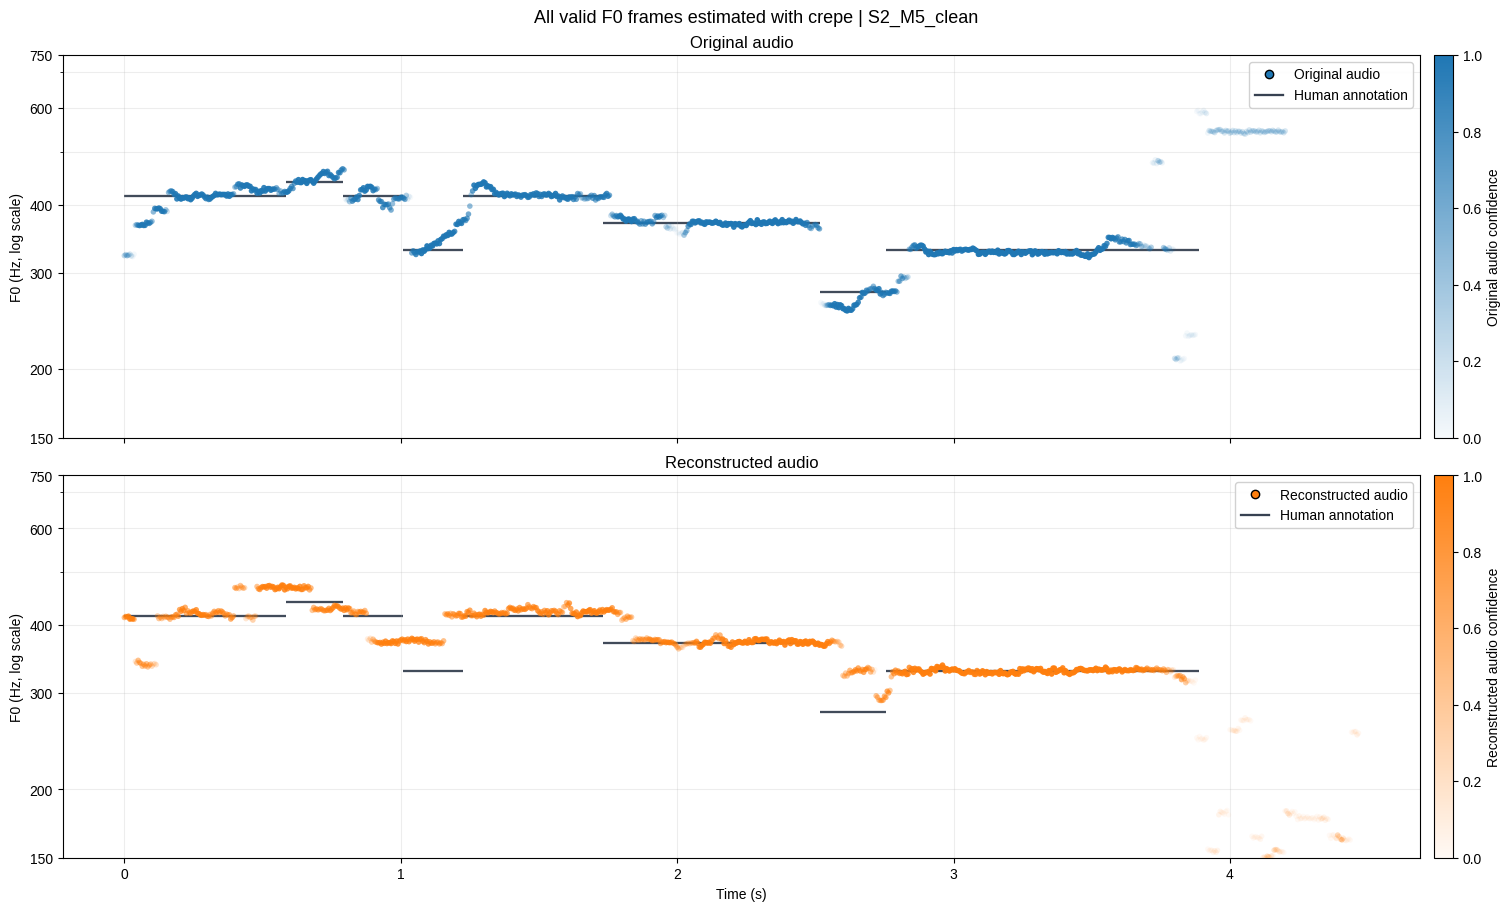

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

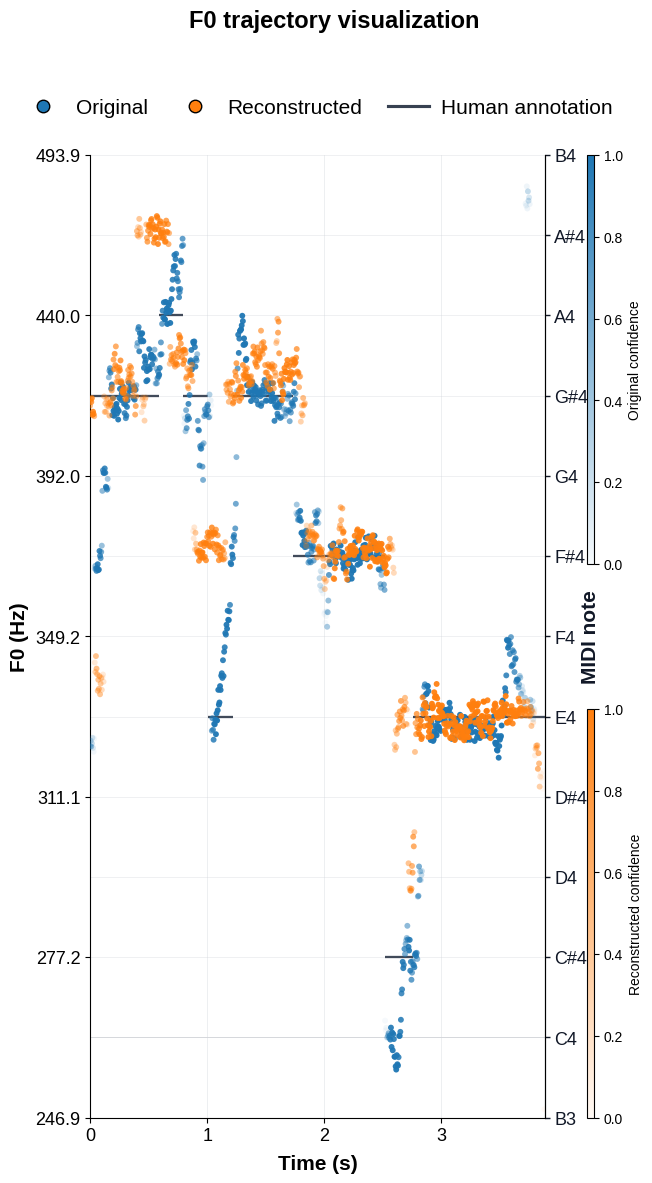

Case: S2_M5 | Estimator: CREPE


In [69]:
display(note_table[["note_index", "start_time_s", "end_time_s", "label_midi", "label_hz"]])


from matplotlib.lines import Line2D
import matplotlib.colors as mcolors


def confidence_to_alpha(confidence, alpha_min=0.04, alpha_max=1.0):
    """保留极低 confidence frame 的微弱可见性，同时让 0--1 控制透明度。"""
    confidence = np.nan_to_num(
        np.asarray(confidence, dtype=np.float64), nan=0.0, posinf=1.0, neginf=0.0
    )
    return alpha_min + (alpha_max - alpha_min) * np.clip(confidence, 0.0, 1.0)


def rgba_with_confidence(base_color, confidence):
    rgb = np.asarray(mcolors.to_rgb(base_color), dtype=np.float64)
    rgba = np.empty((len(confidence), 4), dtype=np.float64)
    rgba[:, :3] = rgb
    rgba[:, 3] = confidence_to_alpha(confidence)
    return rgba


def confidence_alpha_cmap(base_color, name):
    rgb = np.asarray(mcolors.to_rgb(base_color), dtype=np.float64)
    return mcolors.LinearSegmentedColormap.from_list(
        name,
        [(rgb[0], rgb[1], rgb[2], 0.04), (rgb[0], rgb[1], rgb[2], 1.0)],
    )


def confidence_mappable(base_color, name):
    mappable = plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=0.0, vmax=1.0),
        cmap=confidence_alpha_cmap(base_color, name),
    )
    mappable.set_array([])
    return mappable


HUMAN_NOTE_COLOR = "#374151"


def add_human_note_segments(ax):
    for index, note in enumerate(note_table.itertuples(index=False)):
        ax.hlines(
            note.label_hz, note.start_time_s, note.end_time_s,
            color=HUMAN_NOTE_COLOR, linewidth=1.65, alpha=0.95,
            label="Human annotation" if index == 0 else None,
            zorder=1,
        )


def style_f0_axis(ax):
    ax.set_yscale("log")
    ax.set_ylim(f0_config["fmin"], f0_config["fmax"])
    pitch_ticks = [150, 200, 300, 400, 600, 750]
    ax.set_yticks([value for value in pitch_ticks if f0_config["fmin"] <= value <= f0_config["fmax"]])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.set_ylabel("F0 (Hz, log scale)")
    ax.grid(alpha=0.22, which="both")
    apply_time_view(ax)


fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=True, constrained_layout=True)
f0_plot_items = [
    (axes[0], "Original audio", f0_tracks["reference"], "tab:blue"),
    (axes[1], "Reconstructed audio", f0_tracks["reconstructed"], "tab:orange"),
]
for index, (ax, title, track, color) in enumerate(f0_plot_items):
    valid = np.isfinite(track.f0_hz) & (track.f0_hz > 0)
    ax.scatter(
        track.time_sec[valid], track.f0_hz[valid],
        c=rgba_with_confidence(color, track.confidence[valid]),
        s=16, marker="o", linewidths=0, rasterized=True, zorder=3,
    )
    add_human_note_segments(ax)
    style_f0_axis(ax)
    ax.set_title(title)
    legend_items = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markersize=6, label=title),
        Line2D([0], [0], color=HUMAN_NOTE_COLOR, linewidth=1.65, label="Human annotation"),
    ]
    ax.legend(handles=legend_items, loc="upper right", framealpha=0.9)
    panel_cbar = fig.colorbar(
        confidence_mappable(color, f"panel_confidence_{index}"),
        ax=ax, pad=0.01, fraction=0.025,
    )
    panel_cbar.set_label(f"{title} confidence")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"All valid F0 frames estimated with {F0_BACKEND} | {pair_id}", fontsize=13)
plt.show()

# 全部有效 F0 frame 叠加；两种音频使用同一 marker，confidence 只控制透明度。
ESTIMATOR_DISPLAY_NAMES = {
    "crepe": "CREPE", "pesto": "PESTO", "pyin": "pYIN",
    "rmvpe": "RMVPE", "swiftf0": "SwiftF0", "swipe": "SWIPE'",
}
MIDI_NOTE_NAMES = ("C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B")


def midi_note_label(midi_number):
    midi_number = int(midi_number)
    return f"{MIDI_NOTE_NAMES[midi_number % 12]}{midi_number // 12 - 1}"


def hz_to_midi_axis(frequency_hz):
    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)
    return 69.0 + 12.0 * np.log2(np.maximum(frequency_hz, np.finfo(float).tiny) / 440.0)


def midi_to_hz_axis(midi_number):
    return 440.0 * 2.0 ** ((np.asarray(midi_number, dtype=np.float64) - 69.0) / 12.0)


def combined_f0_display_limits(tracks, padding_semitones=1.0, frame_mask=None):
    values = []
    for track in tracks:
        valid = np.isfinite(track.f0_hz) & (track.f0_hz > 0)
        if frame_mask is not None:
            valid &= frame_mask(track.time_sec)
        values.append(np.asarray(track.f0_hz[valid], dtype=np.float64))
    values = np.concatenate(values)
    if len(values) == 0:
        raise ValueError("No valid F0 values are available for the overlay y-axis.")
    padding_factor = 2.0 ** (float(padding_semitones) / 12.0)
    return float(values.min() / padding_factor), float(values.max() * padding_factor)


def add_publication_f0_axes(ax, y_min_hz, y_max_hz):
    ax.set_yscale("log")
    ax.set_ylim(y_min_hz, y_max_hz)
    midi_min = int(np.ceil(hz_to_midi_axis(y_min_hz)))
    midi_max = int(np.floor(hz_to_midi_axis(y_max_hz)))
    midi_values = np.arange(midi_min, midi_max + 1, dtype=int)
    midi_frequencies = midi_to_hz_axis(midi_values)

    for midi_number, frequency_hz in zip(midi_values, midi_frequencies):
        is_c_note = midi_number % 12 == 0
        ax.axhline(
            frequency_hz, color="#6B7280",
            linewidth=0.65 if is_c_note else 0.45,
            alpha=0.30 if is_c_note else 0.16, zorder=0,
        )

    max_left_ticks = 8
    left_tick_step = max(1, int(np.ceil(len(midi_values) / max_left_ticks)))
    left_midi_values = midi_values[::left_tick_step]
    if len(left_midi_values) and left_midi_values[-1] != midi_values[-1]:
        left_midi_values = np.append(left_midi_values, midi_values[-1])
    left_frequencies = midi_to_hz_axis(left_midi_values)
    ax.set_yticks(left_frequencies)
    ax.set_yticklabels([f"{frequency_hz:.1f}" for frequency_hz in left_frequencies])
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_ylabel("F0 (Hz)", labelpad=4.5, fontsize=15, fontweight="bold")
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=13,  # 修改 x、左 y 轴数字字号
    )

    midi_axis = ax.secondary_yaxis(
        "right", functions=(hz_to_midi_axis, midi_to_hz_axis)
    )
    midi_axis.set_yticks(midi_values)
    midi_axis.set_yticklabels([midi_note_label(value) for value in midi_values])
    midi_axis.tick_params(axis="y", labelsize=13, colors="#111827", pad=3, width=1.0)
    midi_axis.spines["right"].set_color("#111827")

    ax.grid(False)
    ax.grid(axis="x", color="#D1D5DB", linewidth=0.6, alpha=0.45)
    ax.spines[["top"]].set_visible(False)
    apply_time_view(ax)
    return midi_axis


overlay_items = [
    ("Original", f0_tracks["reference"], "tab:blue"),
    ("Reconstructed", f0_tracks["reconstructed"], "tab:orange"),
]
human_time_start_sec = float(note_table["start_time_s"].min())
human_time_end_sec = float(note_table["end_time_s"].max())
if not (np.isfinite(human_time_start_sec) and np.isfinite(human_time_end_sec)):
    raise ValueError("Human note label time limits contain non-finite values.")
if human_time_end_sec <= human_time_start_sec:
    raise ValueError("Human note label end time must be later than its start time.")
human_time_limits = (human_time_start_sec, human_time_end_sec)
human_note_starts = note_table["start_time_s"].to_numpy(dtype=np.float64)
human_note_ends = note_table["end_time_s"].to_numpy(dtype=np.float64)


def in_human_note_intervals(time_sec):
    """Return frames that belong to at least one annotated human-note interval."""
    time_sec = np.asarray(time_sec, dtype=np.float64)
    return np.any(
        (time_sec[..., np.newaxis] >= human_note_starts)
        & (time_sec[..., np.newaxis] <= human_note_ends),
        axis=-1,
    )
# 自动锁定y轴范围
# overlay_y_min_hz, overlay_y_max_hz = combined_f0_display_limits(
#     [item[1] for item in overlay_items],
#     padding_semitones=F0_DISPLAY_PADDING_SEMITONES,
#     frame_mask=in_human_note_intervals,
# )

# 手动设定y轴范围
# 手动设置右侧 MIDI note 范围
OVERLAY_MIDI_MIN = 59   # C3
OVERLAY_MIDI_MAX = 71   # C6

overlay_y_min_hz = float(midi_to_hz_axis(OVERLAY_MIDI_MIN))
overlay_y_max_hz = float(midi_to_hz_axis(OVERLAY_MIDI_MAX))

# Figma typography: Arial is preferred; Liberation Sans keeps local rendering stable when Arial is unavailable.
plt.rcParams["font.family"] = ["Arial", "Liberation Sans"]

fig = plt.figure(figsize=(6.5, 12.5), constrained_layout=True)
overlay_grid = fig.add_gridspec(1, 2, width_ratios=[35, 0.55], wspace=0.18)
ax = fig.add_subplot(overlay_grid[0, 0])
confidence_grid = overlay_grid[0, 1].subgridspec(
    3, 1, height_ratios=[1.0, 0.18, 1.0], hspace=0.12
)
original_cbar_ax = fig.add_subplot(confidence_grid[0, 0])
midi_label_ax = fig.add_subplot(confidence_grid[1, 0])
reconstructed_cbar_ax = fig.add_subplot(confidence_grid[2, 0])
midi_label_ax.set_axis_off()
midi_label_ax.text(
    0.5, 0.5, "MIDI note", transform=midi_label_ax.transAxes,
    rotation=90, ha="center", va="center", color="#111827",
    fontsize=15, fontweight="bold",
)
for label, track, color in overlay_items:
    valid = (
        np.isfinite(track.f0_hz) & (track.f0_hz > 0)
        & in_human_note_intervals(track.time_sec)
    )
    ax.scatter(
        track.time_sec[valid], track.f0_hz[valid],
        c=rgba_with_confidence(color, track.confidence[valid]),
        s=18, marker="o", linewidths=0, rasterized=True, zorder=3,
    )
add_human_note_segments(ax)
overlay_midi_axis = add_publication_f0_axes(ax, overlay_y_min_hz, overlay_y_max_hz)
ax.set_xlim(*human_time_limits)
integer_time_ticks = np.arange(
    np.ceil(human_time_start_sec), np.floor(human_time_end_sec) + 1, dtype=int
)
if integer_time_ticks.size:
    ax.set_xticks(integer_time_ticks)
ax.set_xlabel("Time (s)", labelpad=7, fontsize=15, fontweight="bold")
estimator_display_name = ESTIMATOR_DISPLAY_NAMES.get(F0_BACKEND, F0_BACKEND)
fig.suptitle("F0 trajectory visualization", fontsize=17, fontweight="semibold")
overlay_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:blue", markersize=9, label="Original"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:orange", markersize=9, label="Reconstructed"),
    Line2D([0], [0], color=HUMAN_NOTE_COLOR, linewidth=2.25, label="Human annotation"),
]
ax.legend(
    handles=overlay_legend, loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=3, fontsize=15,
    frameon=False, handletextpad=0.55, columnspacing=1.25,
)
original_cbar = fig.colorbar(
    confidence_mappable("tab:blue", "overlay_original_confidence"),
    cax=original_cbar_ax, orientation="vertical",
)
original_cbar.set_label("Original confidence")
reconstructed_cbar = fig.colorbar(
    confidence_mappable("tab:orange", "overlay_reconstructed_confidence"),
    cax=reconstructed_cbar_ax, orientation="vertical",
)
reconstructed_cbar.set_label("Reconstructed confidence")
plt.show()
print(f"Case: S{S_ID}_M{M_ID} | Estimator: {estimator_display_name}")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

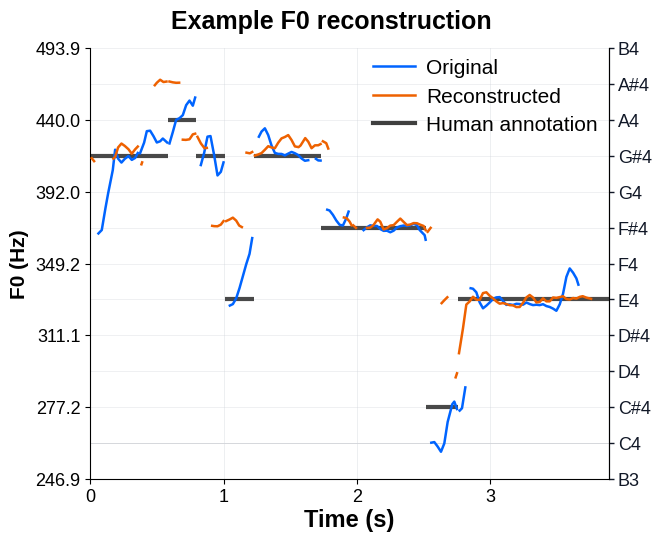

In [73]:
# Fig. 1 panel: publication-style F0 trajectories.
# This cell is display-only: it does not alter the F0 tracks or any PDA computation.
FIG1_CONFIDENCE_THRESHOLD = PRIMARY_CONFIDENCE_THRESHOLD
FIG1_BIN_WIDTH_SEC = 0.025  # 25 ms median bins; display-only aggregation.
FIG1_SMOOTHING_WINDOW_SEC = 0.05  # Local median smoothing within each note; set 0.0 to disable.
FIG1_MAX_JUMP_CENTS = 150.0  # Larger adjacent jumps are shown as discontinuities, not connected lines.
FIG1_TRAJECTORY_LINEWIDTH = 1.8
FIG1_RESTRICT_TO_HUMAN_INTERVALS = True
FIG1_ORIGINAL_COLOR = "#0064FF"
FIG1_RECONSTRUCTED_COLOR = "#EE6100"
FIG1_ANNOTATION_COLOR = "#3F3F3F"


def smooth_f0_segment(f0_hz, smoothing_window_sec, bin_width_sec):
    """Apply a local median smoother to one already-continuous note segment."""
    if smoothing_window_sec <= 0:
        return np.asarray(f0_hz, dtype=np.float64)
    window_bins = max(1, int(round(smoothing_window_sec / bin_width_sec)))
    return pd.Series(f0_hz).rolling(window_bins, center=True, min_periods=1).median().to_numpy()


def aggregate_f0_for_display(
    track, confidence_threshold, bin_width_sec, smoothing_window_sec, max_jump_cents,
    restrict_to_human_intervals=True,
):
    """Aggregate valid frames note-by-note and split gaps or implausible pitch jumps."""
    if not 0 < bin_width_sec <= 0.03:
        raise ValueError("bin_width_sec must be in (0, 0.03] for display-only aggregation.")
    if smoothing_window_sec < 0:
        raise ValueError("smoothing_window_sec must be non-negative.")
    if max_jump_cents is not None and max_jump_cents <= 0:
        raise ValueError("max_jump_cents must be positive or None.")

    valid = (
        np.isfinite(track.time_sec)
        & np.isfinite(track.f0_hz) & (track.f0_hz > 0)
        & np.isfinite(track.confidence) & (track.confidence >= confidence_threshold)
    )
    if restrict_to_human_intervals:
        note_intervals = note_table[["start_time_s", "end_time_s"]].itertuples(index=False, name=None)
    else:
        note_intervals = [(human_time_start_sec, human_time_end_sec)]

    segments = []
    for note_start_sec, note_end_sec in note_intervals:
        note_valid = valid & (track.time_sec >= note_start_sec) & (track.time_sec <= note_end_sec)
        time_sec = np.asarray(track.time_sec[note_valid], dtype=np.float64)
        f0_hz = np.asarray(track.f0_hz[note_valid], dtype=np.float64)
        if time_sec.size == 0:
            continue

        order = np.argsort(time_sec)
        time_sec, f0_hz = time_sec[order], f0_hz[order]
        bin_index = np.floor((time_sec - note_start_sec) / bin_width_sec).astype(int)
        unique_bins, inverse = np.unique(bin_index, return_inverse=True)
        binned_time = np.array([np.median(time_sec[inverse == index]) for index in range(len(unique_bins))])
        binned_f0 = np.array([np.median(f0_hz[inverse == index]) for index in range(len(unique_bins))])

        # Missing bins and large pitch jumps both create a hard trajectory break.
        missing_bin_breaks = np.diff(unique_bins) > 1
        jump_breaks = np.zeros(len(unique_bins) - 1, dtype=bool)
        if max_jump_cents is not None and len(unique_bins) > 1:
            jump_cents = 1200.0 * np.abs(np.diff(np.log2(binned_f0)))
            jump_breaks = jump_cents > max_jump_cents
        split_points = np.flatnonzero(missing_bin_breaks | jump_breaks) + 1

        for segment_time, segment_f0 in zip(np.split(binned_time, split_points), np.split(binned_f0, split_points)):
            smoothed_f0 = smooth_f0_segment(segment_f0, smoothing_window_sec, bin_width_sec)
            segments.append((segment_time, smoothed_f0))
    return segments


def add_fig1_human_annotation(ax, color=FIG1_ANNOTATION_COLOR):
    """Draw only the annotated horizontal note intervals; do not connect note boundaries."""
    for index, note in enumerate(note_table.itertuples(index=False)):
        ax.hlines(
            note.label_hz, note.start_time_s, note.end_time_s,
            color=color, linewidth=3.0, alpha=0.95, zorder=2,
            label="Human annotation" if index == 0 else None,
        )


def plot_fig1_f0_trajectory(
    tracks,
    confidence_threshold=FIG1_CONFIDENCE_THRESHOLD,
    bin_width_sec=FIG1_BIN_WIDTH_SEC,
    smoothing_window_sec=FIG1_SMOOTHING_WINDOW_SEC,
    max_jump_cents=FIG1_MAX_JUMP_CENTS,
    y_limits=(overlay_y_min_hz, overlay_y_max_hz),
    restrict_to_human_intervals=FIG1_RESTRICT_TO_HUMAN_INTERVALS,
):
    """Create a publication-ready Original-vs-Reconstructed F0 trajectory panel."""
    plt.rcParams["font.family"] = ["Arial", "Liberation Sans"]
    fig, ax = plt.subplots(figsize=(6.5, 5.3), constrained_layout=True)
    series = [
        ("Original", tracks["reference"], FIG1_ORIGINAL_COLOR),
        ("Reconstructed", tracks["reconstructed"], FIG1_RECONSTRUCTED_COLOR),
    ]

    legend_handles = []
    for label, track, color in series:
        segments = aggregate_f0_for_display(
            track, confidence_threshold, bin_width_sec, smoothing_window_sec, max_jump_cents,
            restrict_to_human_intervals,
        )
        for time_sec, f0_hz in segments:
            if time_sec.size >= 2:
                ax.plot(time_sec, f0_hz, color=color, linewidth=FIG1_TRAJECTORY_LINEWIDTH, zorder=3)
        legend_handles.append(
            Line2D([0], [0], color=color, linewidth=FIG1_TRAJECTORY_LINEWIDTH, label=label)
        )

    add_fig1_human_annotation(ax)
    add_publication_f0_axes(ax, *y_limits)
    ax.set_xlim(*human_time_limits)
    integer_time_ticks = np.arange(
        np.ceil(human_time_start_sec), np.floor(human_time_end_sec) + 1, dtype=int
    )
    if integer_time_ticks.size:
        ax.set_xticks(integer_time_ticks)
    ax.set_xlabel("Time (s)", labelpad=1.75, fontsize=17, fontweight="bold")
    fig.suptitle("Example F0 reconstruction", fontsize=18, fontweight="bold")
    legend_handles.append(
        Line2D([0], [0], color=FIG1_ANNOTATION_COLOR, linewidth=3.0, label="Human annotation")
    )
    ax.legend(
        handles=legend_handles, loc="upper right", bbox_to_anchor=(0.995, 0.995),
        ncol=1, alignment="left", frameon=False, fontsize=15, handletextpad=0.55,
        labelspacing=0.45, borderaxespad=0.0,
    )
    return fig, ax


fig1_f0_figure, fig1_f0_axis = plot_fig1_f0_trajectory(f0_tracks)
plt.show()
